# Analiza logów - notebook prezentacyjny

Notebook prowadzi przez pipeline projektu: surowe logi -> parser -> `AnalysisConfig` -> CLI (`argparse`) -> `analyze_log_file()` -> `AnalysisResult` -> statystyki -> wizualizacja -> OpenMP-like -> MPI -> CUDA.

Celem jest pokazanie wyniku oraz uzasadnienie, skąd biorą się dane w raportach i wykresach.

## Plan notebooka

1. Przygotowanie środowiska i wejścia.
2. Parsowanie logów oraz konfiguracja analizy.
3. Praca z CLI: frazy, poziomy, daty i eksport.
4. Statystyki i wizualizacje.
5. Porównanie OpenMP-like, MPI i CUDA.
6. Artefakty końcowe do raportu.

## 0) Importy i ustawienia

In [1]:
from datetime import datetime
from pathlib import Path
import subprocess
import sys
import json
import pandas as pd

from IPython.display import Image, Markdown, display

from config import DEFAULT_INPUT_LOG, DEFAULT_LEVELS, DEFAULT_PHRASES, REPORTS_DIR
from domain.models import AnalysisConfig
from processing.analyzer import analyze_log_file
from processing.statistics import total_parsed_ratio, total_matched_ratio, top_error_hours
from processing.top_words import top_words
from report import result_to_dict, save_report_json, save_filtered_lines_csv
from parallel.cuda.benchmark import benchmark_cuda
from visualization.plots import (
    plot_errors_per_hour,
    plot_parallel_comparison,
    plot_level_counts,
    plot_level_filter_comparison,
    plot_top_words,
    plot_cpu_gpu_comparison,
)

In [2]:
INPUT_LOG = str(DEFAULT_INPUT_LOG)
REPORTS = Path("reports")
PLOTS = REPORTS / "plots"
REPORTS.mkdir(parents=True, exist_ok=True)
PLOTS.mkdir(parents=True, exist_ok=True)
INPUT_LOG

'C:\\Users\\PC\\PycharmProjects\\prir_projekt\\data\\raw\\Hadoop_200k.log'

## 1) Parsowanie i pipeline

Wejściem są surowe logi Hadoop. Parser przekształca je w rekordy, a `analyze_log_file()` zwraca `AnalysisResult` z podsumowaniem, filtrami i statystykami czasowymi.

In [3]:
config_preview = AnalysisConfig.from_iterables(
    phrases=DEFAULT_PHRASES,
    levels=DEFAULT_LEVELS,
)
result_preview = analyze_log_file(INPUT_LOG, config_preview)
report_preview = result_to_dict(result_preview)
report_preview["summary"]

{'total_lines': 200000,
 'parsed_lines': 200000,
 'parse_errors': 0,
 'matched_lines': 200000}

In [4]:
print("Przykładowe linie dopasowane przez aktualny filtr (pierwsze 5):")
for line in result_preview.filtered_lines[:5]:
    print(line)

Przykładowe linie dopasowane przez aktualny filtr (pierwsze 5):
2015-10-01 00:00:21,000 ERROR [main] Speculator: INFO user login successful
2015-10-01 00:02:17,000 INFO [main] JobHistoryUtils: Heartbeat received
2015-10-01 00:02:21,000 INFO [main] JobHistoryUtils: ERROR failed to allocate container
2015-10-01 00:02:49,000 INFO [main] AsyncDispatcher: WARNING memory usage high
2015-10-01 00:03:25,000 INFO [main] AsyncDispatcher: FATAL application crashed


In [5]:
date_min = None
date_max = None
if result_preview.filtered_lines:
    # Podgląd tekstowy; zakres dat ustawiamy w konfiguracji albo przez CLI.
    pass
{"pipeline": "raw logs -> AnalysisConfig -> analyze_log_file -> AnalysisResult"}

{'pipeline': 'raw logs -> AnalysisConfig -> analyze_log_file -> AnalysisResult'}

## 2) Konfiguracja analizy (`AnalysisConfig`)

Domyślnie analizowane są wszystkie logi (`phrases=()`, `levels=()`). Opcjonalnie można ustawić `phrases`, `levels`, `date_from`, `date_to`, `error_type` i `limit`.

In [6]:
config = AnalysisConfig.from_iterables(
    phrases=DEFAULT_PHRASES,
    levels=DEFAULT_LEVELS,
)
config

AnalysisConfig(phrases=(), levels=(), error_type='ERROR', limit=None, date_from=None, date_to=None)

## 3) Główna analiza

Funkcja `analyze_log_file(file_path, config)` wykonuje parsowanie, zliczanie poziomów logów, zliczanie fraz, filtrowanie oraz agregację zdarzeń w czasie.

In [7]:
result = analyze_log_file(INPUT_LOG, config)
report = result_to_dict(result)
report["summary"]

{'total_lines': 200000,
 'parsed_lines': 200000,
 'parse_errors': 0,
 'matched_lines': 200000}

## 4) Analiza fraz przez CLI (`--phrase`)

Poniższe przykłady pokazują, jak uruchomić mechanizm z linii poleceń dla wybranych fraz.

In [8]:
commands = [
    [sys.executable, "main.py", "--input", INPUT_LOG, "--phrase", "ERROR", "--limit", "10"],
    [sys.executable, "main.py", "--input", INPUT_LOG, "--phrase", "WARNING", "--limit", "10"],
    [sys.executable, "main.py", "--input", INPUT_LOG, "--phrase", "INFO", "--limit", "10"],
]
for cmd in commands:
    print("\n$", " ".join(cmd))
    completed = subprocess.run(cmd, capture_output=True, text=True)
    print(completed.stdout[:2500])
    if completed.returncode != 0:
        print(completed.stderr)
        raise RuntimeError("CLI phrase command failed")


$ C:\Users\PC\AppData\Local\Programs\Python\Python313\python.exe main.py --input C:\Users\PC\PycharmProjects\prir_projekt\data\raw\Hadoop_200k.log --phrase ERROR --limit 10

=== SUMMARY ===
Total lines: 200000
Parsed lines: 200000
Parse errors: 0

=== PHRASE COUNTS ===
ERROR: 49904

=== LEVEL COUNTS (ALL DETECTED) ===
ERROR: 23910
FATAL: 5893
INFO: 140105
WARN: 30092

=== ERRORS PER HOUR ===
2015-10-01 00:00 -> 7
2015-10-01 01:00 -> 7
2015-10-01 02:00 -> 5
2015-10-01 03:00 -> 8
2015-10-01 04:00 -> 10
2015-10-01 05:00 -> 4
2015-10-01 06:00 -> 9
2015-10-01 07:00 -> 7
2015-10-01 08:00 -> 3
2015-10-01 09:00 -> 6

=== FILTERED LINES (first 10) ===
2015-10-01 00:02:21,000 INFO [main] JobHistoryUtils: ERROR failed to allocate container
2015-10-01 00:07:29,000 FATAL [main] AsyncDispatcher: ERROR failed to allocate container
2015-10-01 00:08:48,000 INFO [main] ContainerAllocator: ERROR failed to allocate container
2015-10-01 00:10:37,000 WARN [main] ContainerAllocator: ERROR connection timeout

## 5) Wyodrębnianie wierszy spełniających kryteria

Poniższe przykłady obejmują filtrowanie po poziomie logu, zakresie dat oraz frazie. Wyniki można przeglądać w notebooku albo zapisać do CSV.

In [9]:
cmd = [
    sys.executable, "main.py",
    "--input", INPUT_LOG,
    "--filter-level", "ERROR",
    "--show-level-counts",
    "--limit", "10",
]
print("$", " ".join(cmd))
completed = subprocess.run(cmd, capture_output=True, text=True)
print(completed.stdout[:3000])
if completed.returncode != 0:
    print(completed.stderr)
    raise RuntimeError("CLI filter-level command failed")

$ C:\Users\PC\AppData\Local\Programs\Python\Python313\python.exe main.py --input C:\Users\PC\PycharmProjects\prir_projekt\data\raw\Hadoop_200k.log --filter-level ERROR --show-level-counts --limit 10

=== SUMMARY ===
Total lines: 200000
Parsed lines: 200000
Parse errors: 0

=== PHRASE COUNTS ===

=== LEVEL COUNTS (ALL DETECTED) ===
ERROR: 23910
FATAL: 5893
INFO: 140105
WARN: 30092

=== ERRORS PER HOUR ===
2015-10-01 00:00 -> 7
2015-10-01 01:00 -> 7
2015-10-01 02:00 -> 5
2015-10-01 03:00 -> 8
2015-10-01 04:00 -> 10
2015-10-01 05:00 -> 4
2015-10-01 06:00 -> 9
2015-10-01 07:00 -> 7
2015-10-01 08:00 -> 3
2015-10-01 09:00 -> 6

=== FILTERED LINES (first 10) ===
2015-10-01 00:00:21,000 ERROR [main] Speculator: INFO user login successful
2015-10-01 00:19:49,000 ERROR [main] JobHistoryUtils: Registering dispatcher
2015-10-01 00:24:49,000 ERROR [main] AsyncDispatcher: Container allocation successful
2015-10-01 00:28:58,000 ERROR [main] Speculator: ERROR failed to allocate container
2015-10-01 00

In [10]:
cmd = [
    sys.executable, "main.py",
    "--input", INPUT_LOG,
    "--start-date", "2015-10-18",
    "--end-date", "2023-12-31",
    "--show-level-counts",
    "--limit", "10",
]
print("$", " ".join(cmd))
completed = subprocess.run(cmd, capture_output=True, text=True)
print(completed.stdout[:3000])
if completed.returncode != 0:
    print(completed.stderr)
    raise RuntimeError("CLI date-range command failed")

$ C:\Users\PC\AppData\Local\Programs\Python\Python313\python.exe main.py --input C:\Users\PC\PycharmProjects\prir_projekt\data\raw\Hadoop_200k.log --start-date 2015-10-18 --end-date 2023-12-31 --show-level-counts --limit 10

=== SUMMARY ===
Total lines: 200000
Parsed lines: 200000
Parse errors: 0

=== PHRASE COUNTS ===

=== LEVEL COUNTS (ALL DETECTED) ===
ERROR: 23910
FATAL: 5893
INFO: 140105
WARN: 30092

=== ERRORS PER HOUR ===
2015-10-01 00:00 -> 7
2015-10-01 01:00 -> 7
2015-10-01 02:00 -> 5
2015-10-01 03:00 -> 8
2015-10-01 04:00 -> 10
2015-10-01 05:00 -> 4
2015-10-01 06:00 -> 9
2015-10-01 07:00 -> 7
2015-10-01 08:00 -> 3
2015-10-01 09:00 -> 6

=== FILTERED LINES (first 10) ===
2015-10-18 00:01:31,000 INFO [main] ContainerAllocator: Container allocation successful
2015-10-18 00:03:14,000 ERROR [main] ContainerAllocator: Heartbeat received
2015-10-18 00:04:42,000 FATAL [main] ContainerAllocator: Task execution started
2015-10-18 00:04:51,000 INFO [main] Speculator: ERROR connection ti

### 5.2) Eksport wyodrębnionych wierszy

In [11]:
filtered_csv = REPORTS / "filtered_error_lines.csv"
cmd = [
    sys.executable, "main.py",
    "--input", INPUT_LOG,
    "--filter-level", "ERROR",
    "--output-filtered-csv", str(filtered_csv),
]
print("$", " ".join(cmd))
completed = subprocess.run(cmd, capture_output=True, text=True)
print(completed.stdout[:2000])
if completed.returncode != 0:
    print(completed.stderr)
    raise RuntimeError("CLI filtered csv export failed")
filtered_csv

$ C:\Users\PC\AppData\Local\Programs\Python\Python313\python.exe main.py --input C:\Users\PC\PycharmProjects\prir_projekt\data\raw\Hadoop_200k.log --filter-level ERROR --output-filtered-csv reports\filtered_error_lines.csv

=== SUMMARY ===
Total lines: 200000
Parsed lines: 200000
Parse errors: 0

=== PHRASE COUNTS ===

=== LEVEL COUNTS (ALL DETECTED) ===
ERROR: 23910
FATAL: 5893
INFO: 140105
WARN: 30092

=== ERRORS PER HOUR ===
2015-10-01 00:00 -> 7
2015-10-01 01:00 -> 7
2015-10-01 02:00 -> 5
2015-10-01 03:00 -> 8
2015-10-01 04:00 -> 10
2015-10-01 05:00 -> 4
2015-10-01 06:00 -> 9
2015-10-01 07:00 -> 7
2015-10-01 08:00 -> 3
2015-10-01 09:00 -> 6
2015-10-01 10:00 -> 8
2015-10-01 11:00 -> 7
2015-10-01 12:00 -> 10
2015-10-01 13:00 -> 9
2015-10-01 14:00 -> 6
2015-10-01 15:00 -> 11
2015-10-01 16:00 -> 9
2015-10-01 17:00 -> 5
2015-10-01 18:00 -> 10
2015-10-01 19:00 -> 11
2015-10-01 20:00 -> 8
2015-10-01 21:00 -> 10
2015-10-01 22:00 -> 7
2015-10-01 23:00 -> 7
2015-10-02 00:00 -> 5
2015-10-02 0

WindowsPath('reports/filtered_error_lines.csv')

In [12]:
print("Ścieżka do wyodrębnionych wierzy:", filtered_csv)

Wyodrębnione wiersze są zapisane w: reports\filtered_error_lines.csv


### 5.3) Filtrowanie po frazie przez CLI

In [13]:
cmd = [sys.executable, "main.py", "--input", INPUT_LOG, "--phrase", "ERROR", "--limit", "10"]
print("$", " ".join(cmd))
completed = subprocess.run(cmd, capture_output=True, text=True)
print(completed.stdout[:2500])
if completed.returncode != 0:
    print(completed.stderr)
    raise RuntimeError("CLI phrase filter command failed")

$ C:\Users\PC\AppData\Local\Programs\Python\Python313\python.exe main.py --input C:\Users\PC\PycharmProjects\prir_projekt\data\raw\Hadoop_200k.log --phrase ERROR --limit 10

=== SUMMARY ===
Total lines: 200000
Parsed lines: 200000
Parse errors: 0

=== PHRASE COUNTS ===
ERROR: 49904

=== LEVEL COUNTS (ALL DETECTED) ===
ERROR: 23910
FATAL: 5893
INFO: 140105
WARN: 30092

=== ERRORS PER HOUR ===
2015-10-01 00:00 -> 7
2015-10-01 01:00 -> 7
2015-10-01 02:00 -> 5
2015-10-01 03:00 -> 8
2015-10-01 04:00 -> 10
2015-10-01 05:00 -> 4
2015-10-01 06:00 -> 9
2015-10-01 07:00 -> 7
2015-10-01 08:00 -> 3
2015-10-01 09:00 -> 6

=== FILTERED LINES (first 10) ===
2015-10-01 00:02:21,000 INFO [main] JobHistoryUtils: ERROR failed to allocate container
2015-10-01 00:07:29,000 FATAL [main] AsyncDispatcher: ERROR failed to allocate container
2015-10-01 00:08:48,000 INFO [main] ContainerAllocator: ERROR failed to allocate container
2015-10-01 00:10:37,000 WARN [main] ContainerAllocator: ERROR connection timeout


## 6) Statystyki zdarzeń w czasie

Sekcja ta pokazuje liczbę zdarzeń danego typu na godzinę. Parametry CLI `--show-errors-per-hour`, `--error-type`, `--top-error-hours` i `--limit` sterują zakresem prezentowanych wyników.

In [14]:
cmd = [
    sys.executable, "main.py",
    "--input", INPUT_LOG,
    "--show-errors-per-hour",
    "--error-type", "ERROR",
    "--top-error-hours", "10",
    "--limit", "10",
]
print("$", " ".join(cmd))
completed = subprocess.run(cmd, capture_output=True, text=True)
print(completed.stdout[:3000])
if completed.returncode != 0:
    print(completed.stderr)
    raise RuntimeError("CLI errors-per-hour command failed")

$ C:\Users\PC\AppData\Local\Programs\Python\Python313\python.exe main.py --input C:\Users\PC\PycharmProjects\prir_projekt\data\raw\Hadoop_200k.log --show-errors-per-hour --error-type ERROR --top-error-hours 10 --limit 10

=== SUMMARY ===
Total lines: 200000
Parsed lines: 200000
Parse errors: 0

=== PHRASE COUNTS ===

=== LEVEL COUNTS (ALL DETECTED) ===
ERROR: 23910
FATAL: 5893
INFO: 140105
WARN: 30092

=== ERRORS PER HOUR ===
2015-10-01 00:00 -> 7
2015-10-01 01:00 -> 7
2015-10-01 02:00 -> 5
2015-10-01 03:00 -> 8
2015-10-01 04:00 -> 10
2015-10-01 05:00 -> 4
2015-10-01 06:00 -> 9
2015-10-01 07:00 -> 7
2015-10-01 08:00 -> 3
2015-10-01 09:00 -> 6

=== FILTERED LINES (first 10) ===
2015-10-01 00:00:21,000 ERROR [main] Speculator: INFO user login successful
2015-10-01 00:02:17,000 INFO [main] JobHistoryUtils: Heartbeat received
2015-10-01 00:02:21,000 INFO [main] JobHistoryUtils: ERROR failed to allocate container
2015-10-01 00:02:49,000 INFO [main] AsyncDispatcher: WARNING memory usage high

In [15]:
result = analyze_log_file(INPUT_LOG, AnalysisConfig.from_iterables(error_type="ERROR"))
result.errors_per_hour

{'2015-10-01 00:00': 7,
 '2015-10-01 01:00': 7,
 '2015-10-01 02:00': 5,
 '2015-10-01 03:00': 8,
 '2015-10-01 04:00': 10,
 '2015-10-01 05:00': 4,
 '2015-10-01 06:00': 9,
 '2015-10-01 07:00': 7,
 '2015-10-01 08:00': 3,
 '2015-10-01 09:00': 6,
 '2015-10-01 10:00': 8,
 '2015-10-01 11:00': 7,
 '2015-10-01 12:00': 10,
 '2015-10-01 13:00': 9,
 '2015-10-01 14:00': 6,
 '2015-10-01 15:00': 11,
 '2015-10-01 16:00': 9,
 '2015-10-01 17:00': 5,
 '2015-10-01 18:00': 10,
 '2015-10-01 19:00': 11,
 '2015-10-01 20:00': 8,
 '2015-10-01 21:00': 10,
 '2015-10-01 22:00': 7,
 '2015-10-01 23:00': 7,
 '2015-10-02 00:00': 5,
 '2015-10-02 01:00': 11,
 '2015-10-02 02:00': 5,
 '2015-10-02 03:00': 7,
 '2015-10-02 04:00': 8,
 '2015-10-02 05:00': 5,
 '2015-10-02 06:00': 8,
 '2015-10-02 07:00': 4,
 '2015-10-02 08:00': 12,
 '2015-10-02 09:00': 4,
 '2015-10-02 10:00': 5,
 '2015-10-02 11:00': 7,
 '2015-10-02 12:00': 6,
 '2015-10-02 13:00': 7,
 '2015-10-02 14:00': 7,
 '2015-10-02 15:00': 2,
 '2015-10-02 16:00': 9,
 '2015-1

In [16]:
{
    "parsed_ratio": round(total_parsed_ratio(result), 4),
    "matched_ratio": round(total_matched_ratio(result), 4),
    "top_error_hours": top_error_hours(result, top_n=10),
}

{'parsed_ratio': 1.0,
 'matched_ratio': 1.0,
 'top_error_hours': [('2015-12-25 20:00', 17),
  ('2016-01-05 11:00', 17),
  ('2015-10-08 16:00', 16),
  ('2015-11-03 02:00', 16),
  ('2015-11-04 18:00', 16),
  ('2015-11-14 22:00', 16),
  ('2015-10-07 10:00', 15),
  ('2015-11-24 12:00', 15),
  ('2015-12-15 03:00', 15),
  ('2015-12-18 21:00', 15)]}

## 7) Wizualizacja

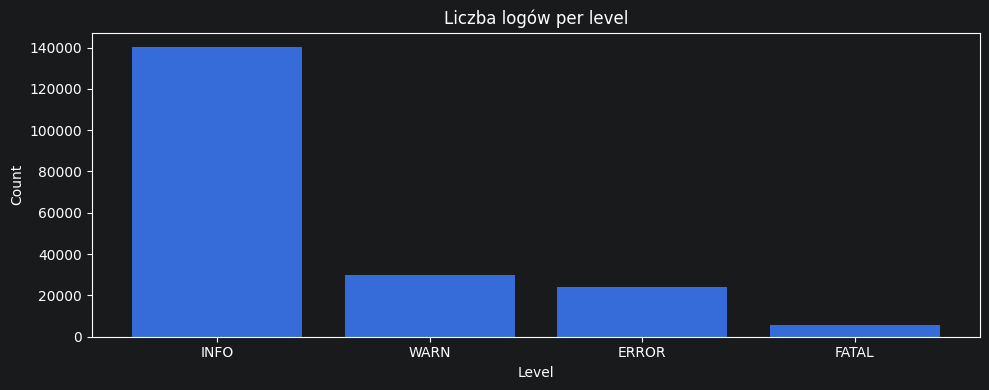

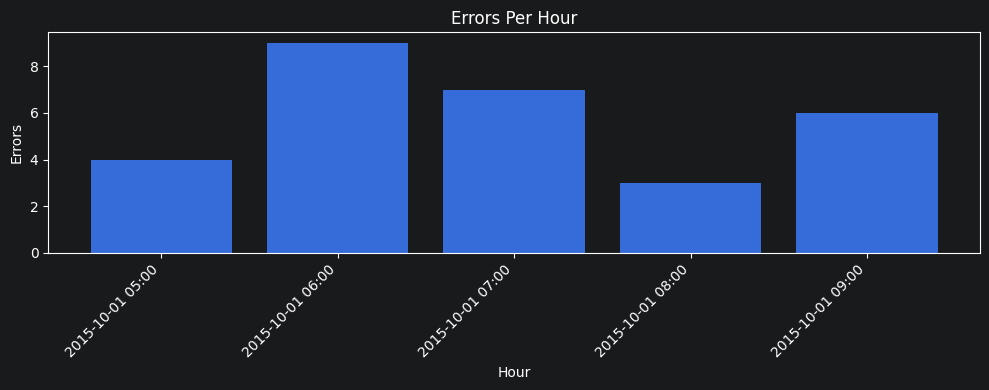

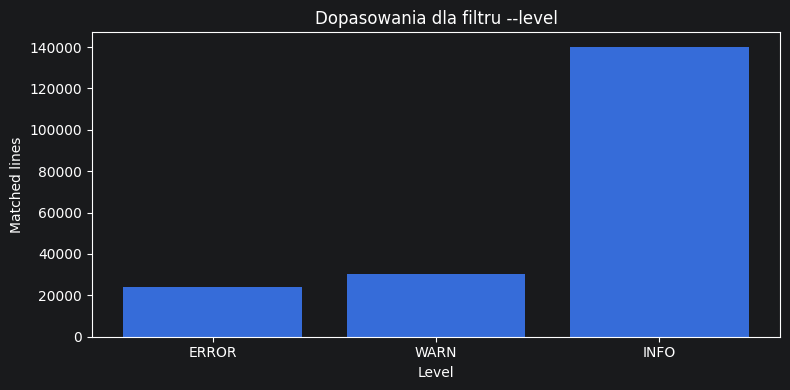

{'ERROR': 23910, 'WARN': 30092, 'INFO': 140105}

In [17]:
# Wykres 1: rozkład poziomów logów
plot_level_counts(result.level_counts)

# Viz 2: błędy per godzina
plot_errors_per_hour(result.errors_per_hour, hour_from="2015-10-01 05:00", hour_to="2015-10-01 09:00")

# Przykład nowego filtrowania po level (jak --level ERROR)
error_only = analyze_log_file(
    INPUT_LOG,
    AnalysisConfig.from_iterables(levels=("ERROR",)),
)
{
    "matched_lines_level_ERROR": len(error_only.filtered_lines),
    "sample": error_only.filtered_lines[:3],
}

# Viz 3: porównanie liczby linii po filtrze --level
level_compare = {
    "ERROR": len(analyze_log_file(INPUT_LOG, AnalysisConfig.from_iterables(levels=("ERROR",))).filtered_lines),
    "WARN": len(analyze_log_file(INPUT_LOG, AnalysisConfig.from_iterables(levels=("WARN",))).filtered_lines),
    "INFO": len(analyze_log_file(INPUT_LOG, AnalysisConfig.from_iterables(levels=("INFO",))).filtered_lines),
}
plot_level_filter_comparison(level_compare)
level_compare

## 8) Eksport wyników (`AnalysisResult`)

In [18]:
json_path = REPORTS / "notebook_report.json"
csv_path = REPORTS / "notebook_filtered.csv"
save_report_json(result, str(json_path))
save_filtered_lines_csv(result, str(csv_path))
json_path, csv_path

(WindowsPath('reports/notebook_report.json'),
 WindowsPath('reports/notebook_filtered.csv'))

### Przejście do benchmarków

W kolejnych sekcjach mierzymy czas, przyspieszenie i efektywność, pamiętając że dla małych danych narzut równoległości może dominować nad zyskiem obliczeniowym.

## 9) OpenMP-like (`main.py --parallel-mode openmp`) + wykresy

Ten wariant realizuje równoległą tokenizację, lokalne słowniki/liczniki i końcową redukcję. W Pythonie przyspieszenie może być ograniczone przez narzut uruchamiania workerów oraz GIL przy obciążeniach CPU-bound.

In [19]:
cmd = [
    sys.executable,
    'main.py',
    '--input', INPUT_LOG,
    '--parallel-mode', 'openmp',
    '--openmp-workers', '4',
]
completed = subprocess.run(cmd, capture_output=True, text=True)
print(completed.stdout)
if completed.returncode != 0:
    print(completed.stderr)
    raise RuntimeError('OpenMP mode failed')


=== SUMMARY ===
Total lines: 200000
Parsed lines: 200000
Parse errors: 0

=== PHRASE COUNTS ===

=== LEVEL COUNTS (ALL DETECTED) ===
ERROR: 23910
FATAL: 5893
INFO: 140105
WARN: 30092

=== ERRORS PER HOUR ===
2015-10-01 00:00 -> 7
2015-10-01 01:00 -> 7
2015-10-01 02:00 -> 5
2015-10-01 03:00 -> 8
2015-10-01 04:00 -> 10
2015-10-01 05:00 -> 4
2015-10-01 06:00 -> 9
2015-10-01 07:00 -> 7
2015-10-01 08:00 -> 3
2015-10-01 09:00 -> 6
2015-10-01 10:00 -> 8
2015-10-01 11:00 -> 7
2015-10-01 12:00 -> 10
2015-10-01 13:00 -> 9
2015-10-01 14:00 -> 6
2015-10-01 15:00 -> 11
2015-10-01 16:00 -> 9
2015-10-01 17:00 -> 5
2015-10-01 18:00 -> 10
2015-10-01 19:00 -> 11
2015-10-01 20:00 -> 8
2015-10-01 21:00 -> 10
2015-10-01 22:00 -> 7
2015-10-01 23:00 -> 7
2015-10-02 00:00 -> 5
2015-10-02 01:00 -> 11
2015-10-02 02:00 -> 5
2015-10-02 03:00 -> 7
2015-10-02 04:00 -> 8
2015-10-02 05:00 -> 5
2015-10-02 06:00 -> 8
2015-10-02 07:00 -> 4
2015-10-02 08:00 -> 12
2015-10-02 09:00 -> 4
2015-10-02 10:00 -> 5
2015-10-02 11

In [20]:
import csv

openmp_csv = REPORTS / "benchmark_openmp.csv"
openmp_plot = PLOTS / "openmp_speedup_efficiency.png"
cmd = [
    sys.executable,
    "openmp_speedup.py",
    "--input", INPUT_LOG,
    "--threads", "1", "2", "4", "8",
    "--backend", "thread",
    "--save-dir", str(REPORTS),
]
print("$", " ".join(cmd))
completed = subprocess.run(cmd, capture_output=True, text=True)
print(completed.stdout)
if completed.returncode != 0:
    print(completed.stderr)
    raise RuntimeError("OpenMP-like benchmark failed")

openmp_rows = []
with open(openmp_csv, "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for i, row in enumerate(reader):
        if i >= 10:
            break
        openmp_rows.append(row)
openmp_rows

$ C:\Users\PC\AppData\Local\Programs\Python\Python313\python.exe openmp_speedup.py --input C:\Users\PC\PycharmProjects\prir_projekt\data\raw\Hadoop_200k.log --threads 1 2 4 8 --backend thread --save-dir reports
   threads      time backend   speedup  efficiency
0        1  0.177333  thread  1.000000    1.000000
1        2  0.197093  thread  0.899746    0.449873
2        4  0.181483  thread  0.977135    0.244284
3        8  0.180014  thread  0.985106    0.123138
Figure(1200x400)



[{'threads': '1',
  'time': '0.1773332999982813',
  'backend': 'thread',
  'speedup': '1.0',
  'efficiency': '1.0'},
 {'threads': '2',
  'time': '0.19709269999657408',
  'backend': 'thread',
  'speedup': '0.8997456526871048',
  'efficiency': '0.4498728263435524'},
 {'threads': '4',
  'time': '0.18148289999953704',
  'backend': 'thread',
  'speedup': '0.9771350358559052',
  'efficiency': '0.2442837589639763'},
 {'threads': '8',
  'time': '0.18001440000080038',
  'backend': 'thread',
  'speedup': '0.9851061914907521',
  'efficiency': '0.12313827393634401'}]

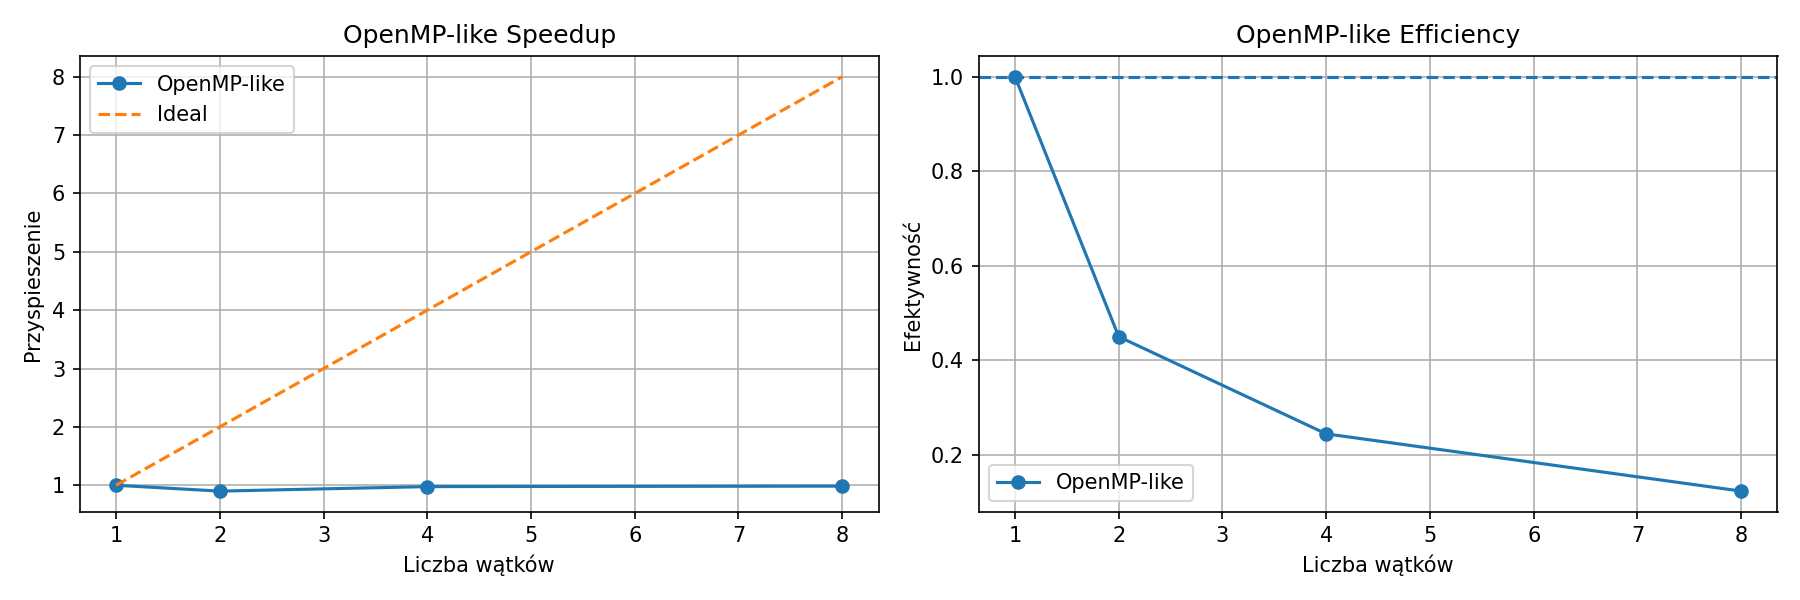

In [21]:
openmp_plot = PLOTS / "openmp_speedup_efficiency.png"
if openmp_plot.exists():
    display(Image(filename=str(openmp_plot)))
else:
    print("Brak wykresu OpenMP-like - uruchom komórkę z benchmarkiem OpenMP-like.")

## 10) MPI (`main.py --parallel-mode mpi`) + wykresy

MPI dzieli dane między procesy, wykonuje lokalne zliczanie tokenów i scala wyniki na procesie root. Jeśli `mpiexec` nie jest dostępny, projekt uruchamia fallback jednego procesu.

In [22]:
from parallel.mpi.launcher import find_mpiexec

mpiexec = find_mpiexec()
if mpiexec:
    cmd = [
        mpiexec, "-n", "4",
        sys.executable,
        "main.py",
        "--input", INPUT_LOG,
        "--parallel-mode", "mpi",
    ]
else:
    print("mpiexec nie jest dostępny - uruchamiam fallback MPI w jednym procesie.")
    cmd = [
        sys.executable,
        "main.py",
        "--input", INPUT_LOG,
        "--parallel-mode", "mpi",
    ]
completed = subprocess.run(cmd, capture_output=True, text=True)
print(completed.stdout)
if completed.returncode != 0:
    print(completed.stderr)
    raise RuntimeError("MPI mode failed (sprawdź instalację mpiexec / MPI i mpi4py).")


=== SUMMARY ===
Total lines: 200000
Parsed lines: 200000
Parse errors: 0

=== PHRASE COUNTS ===

=== LEVEL COUNTS (ALL DETECTED) ===
ERROR: 23910
FATAL: 5893
INFO: 140105
WARN: 30092

=== ERRORS PER HOUR ===
2015-10-01 00:00 -> 7
2015-10-01 01:00 -> 7
2015-10-01 02:00 -> 5
2015-10-01 03:00 -> 8
2015-10-01 04:00 -> 10
2015-10-01 05:00 -> 4
2015-10-01 06:00 -> 9
2015-10-01 07:00 -> 7
2015-10-01 08:00 -> 3
2015-10-01 09:00 -> 6
2015-10-01 10:00 -> 8
2015-10-01 11:00 -> 7
2015-10-01 12:00 -> 10
2015-10-01 13:00 -> 9
2015-10-01 14:00 -> 6
2015-10-01 15:00 -> 11
2015-10-01 16:00 -> 9
2015-10-01 17:00 -> 5
2015-10-01 18:00 -> 10
2015-10-01 19:00 -> 11
2015-10-01 20:00 -> 8
2015-10-01 21:00 -> 10
2015-10-01 22:00 -> 7
2015-10-01 23:00 -> 7
2015-10-02 00:00 -> 5
2015-10-02 01:00 -> 11
2015-10-02 02:00 -> 5
2015-10-02 03:00 -> 7
2015-10-02 04:00 -> 8
2015-10-02 05:00 -> 5
2015-10-02 06:00 -> 8
2015-10-02 07:00 -> 4
2015-10-02 08:00 -> 12
2015-10-02 09:00 -> 4
2015-10-02 10:00 -> 5
2015-10-02 11

In [23]:
import csv
import pandas as pd
from parallel.mpi.runner import run_mpi_token_count
from parallel.mpi.launcher import find_mpiexec
from visualization.plots import plot_speedup_efficiency

mpi_csv = REPORTS / "benchmark_mpi.csv"
mpi_plot = PLOTS / "mpi_speedup_efficiency.png"
if not mpi_csv.exists() or not mpi_plot.exists():
    if find_mpiexec():
        cmd = [
            sys.executable,
            "mpi_speedup.py",
            "--input", INPUT_LOG,
            "--procs", "1", "2", "4", "8",
            "--save-dir", str(REPORTS),
        ]
        print("$", " ".join(cmd))
        completed = subprocess.run(cmd, capture_output=True, text=True)
        print(completed.stdout)
        if completed.returncode != 0:
            print(completed.stderr)
            raise RuntimeError("MPI benchmark failed")
    else:
        print("mpiexec nie jest dostępny - generuję fallbackowy benchmark MPI dla 1 procesu.")
        with open(INPUT_LOG, "r", encoding="utf-8") as handle:
            lines = handle.readlines()
        result = run_mpi_token_count(lines)
        df = pd.DataFrame([{"processes": 1, "time": float(result["time"]), "speedup": 1.0, "efficiency": 1.0}])
        REPORTS.mkdir(parents=True, exist_ok=True)
        PLOTS.mkdir(parents=True, exist_ok=True)
        df.to_csv(mpi_csv, index=False)
        plot_speedup_efficiency([1], [1.0], [1.0], "MPI fallback", "Processes", str(mpi_plot))

mpi_rows = []
with open(mpi_csv, "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for i, row in enumerate(reader):
        if i >= 10:
            break
        mpi_rows.append(row)
mpi_rows

[{'processes': '1',
  'time': '0.21253300000171294',
  'speedup': '1.0',
  'efficiency': '1.0'},
 {'processes': '2',
  'time': '0.13074860000051558',
  'speedup': '1.6255088008657443',
  'efficiency': '0.8127544004328722'},
 {'processes': '4',
  'time': '0.11028499999883934',
  'speedup': '1.927125175717003',
  'efficiency': '0.48178129392925073'},
 {'processes': '8',
  'time': '0.13538189999962924',
  'speedup': '1.569877509492',
  'efficiency': '0.1962346886865'}]

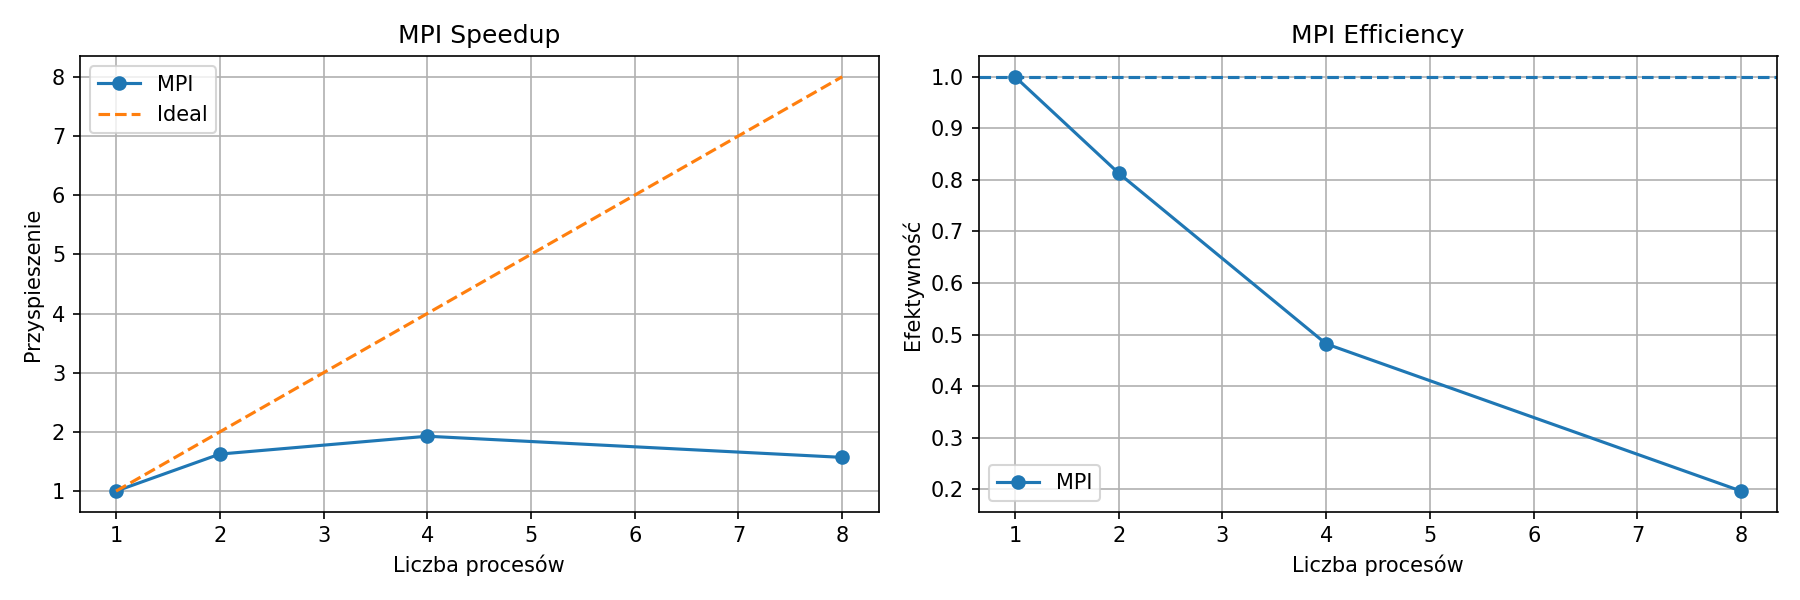

In [24]:
mpi_plot = PLOTS / "mpi_speedup_efficiency.png"
if mpi_plot.exists():
    display(Image(filename=str(mpi_plot)))
else:
    print("Brak wykresu MPI - uruchom komórkę z benchmarkiem MPI albo sprawdź mpiexec / mpi4py.")

## 11) CUDA / GPU (`main.py --parallel-mode cuda`)

CUDA przyspiesza zliczanie tokenów i histogramu bajtów na GPU. Tekst logu jest spłaszczany do bufora bajtów, a kernel CUDA liczy początki tokenów oraz histogram. Jeśli CUDA albo `numba.cuda` nie są dostępne, wynik przechodzi w kontrolowany `cpu-fallback`, dzięki czemu notebook działa także bez GPU.

In [25]:
cmd = [
    sys.executable,
    "main.py",
    "--input", INPUT_LOG,
    "--parallel-mode", "cuda",
    "--cuda-threads-per-block", "256",
    "--limit", "5",
]
print("$", " ".join(cmd))
completed = subprocess.run(cmd, capture_output=True, text=True)
print(completed.stdout)
if completed.stderr:
    print(completed.stderr)

$ C:\Users\PC\AppData\Local\Programs\Python\Python313\python.exe main.py --input C:\Users\PC\PycharmProjects\prir_projekt\data\raw\Hadoop_200k.log --parallel-mode cuda --cuda-threads-per-block 256 --limit 5

=== SUMMARY ===
Total lines: 200000
Parsed lines: 200000
Parse errors: 0

=== PHRASE COUNTS ===

=== LEVEL COUNTS (ALL DETECTED) ===
ERROR: 23910
FATAL: 5893
INFO: 140105
WARN: 30092

=== ERRORS PER HOUR ===
2015-10-01 00:00 -> 7
2015-10-01 01:00 -> 7
2015-10-01 02:00 -> 5
2015-10-01 03:00 -> 8
2015-10-01 04:00 -> 10

=== FILTERED LINES (first 10) ===
2015-10-01 00:00:21,000 ERROR [main] Speculator: INFO user login successful
2015-10-01 00:02:17,000 INFO [main] JobHistoryUtils: Heartbeat received
2015-10-01 00:02:21,000 INFO [main] JobHistoryUtils: ERROR failed to allocate container
2015-10-01 00:02:49,000 INFO [main] AsyncDispatcher: WARNING memory usage high
2015-10-01 00:03:25,000 INFO [main] AsyncDispatcher: FATAL application crashed
Matched lines: 200000

=== CUDA TOKENIZATION

In [26]:
with open(INPUT_LOG, "r", encoding="utf-8") as handle:
    cuda_lines = handle.readlines()

cuda_result = benchmark_cuda(cuda_lines, threads_per_block=256)
cuda_result

{'time': 0.36489000000074157,
 'tokens': 1649983,
 'bytes': 15562516,
 'throughput_gb_s': 0.042649883526455566,
 'nonzero_byte_bins': 58,
 'threads_per_block': 256,
 'blocks': 60792,
 'mode': 'cuda'}

### Artefakty końcowe

Ta część zbiera wyniki w formacie przydatnym do raportu: pliki CSV, wykresy PNG i syntetyczne podsumowanie markdown. Dzięki temu notebook dokumentuje proces, a katalog `reports/` zawiera gotowe artefakty do oddania lub dalszej analizy.

## 12) Wyniki wymagane do raportu

Ta sekcja generuje artefakty do raportu: top-N słów, przepustowość GB/s, porównanie CPU/GPU oraz krótki wniosek o tym, czy I/O jest wąskim gardłem.

In [27]:
cmd = [
    sys.executable,
    "benchmark_report.py",
    "--input", INPUT_LOG,
    "--openmp-workers", "4",
    "--cuda-threads-per-block", "256",
    "--top-n", "20",
    "--save-dir", str(REPORTS),
]
print("$", " ".join(cmd))
completed = subprocess.run(cmd, capture_output=True, text=True)
print(completed.stdout)
if completed.stderr:
    print(completed.stderr)

$ C:\Users\PC\AppData\Local\Programs\Python\Python313\python.exe benchmark_report.py --input C:\Users\PC\PycharmProjects\prir_projekt\data\raw\Hadoop_200k.log --openmp-workers 4 --cuda-threads-per-block 256 --top-n 20 --save-dir reports
        technology       mode      time  throughput_gb_s   tokens
0  CPU OpenMP-like  4 workers  0.170246         0.091412  1649983
1         GPU CUDA       cuda  0.231264         0.067293  1649983
Saved report to: reports\benchmark_report.md



In [28]:
cpu_gpu_csv = REPORTS / "benchmark_cpu_gpu.csv"
top_words_csv = REPORTS / "top_words.csv"

cpu_gpu_df = pd.read_csv(cpu_gpu_csv)
top_words_df = pd.read_csv(top_words_csv)

display(cpu_gpu_df)
display(top_words_df.head(20))

,technology,mode,time,throughput_gb_s,tokens
0,CPU OpenMP-like,4 workers,0.170246,0.091412,1649983
1,GPU CUDA,cuda,0.231264,0.067293,1649983


,word,count
0,000,200000
1,MAIN,200000
2,INFO,173322
3,ERROR,73814
4,MRAPPMASTER,33527
5,SPECULATOR,33515
6,TASK,33473
7,WARNING,33466
8,CONTAINERALLOCATOR,33455
9,CONTAINER,33437


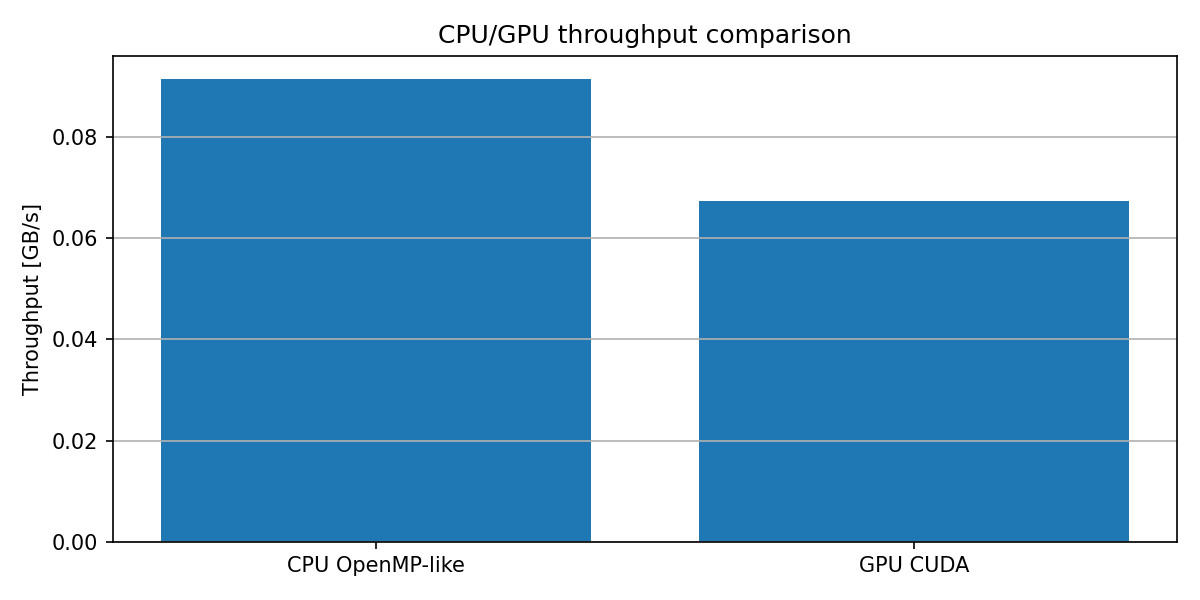

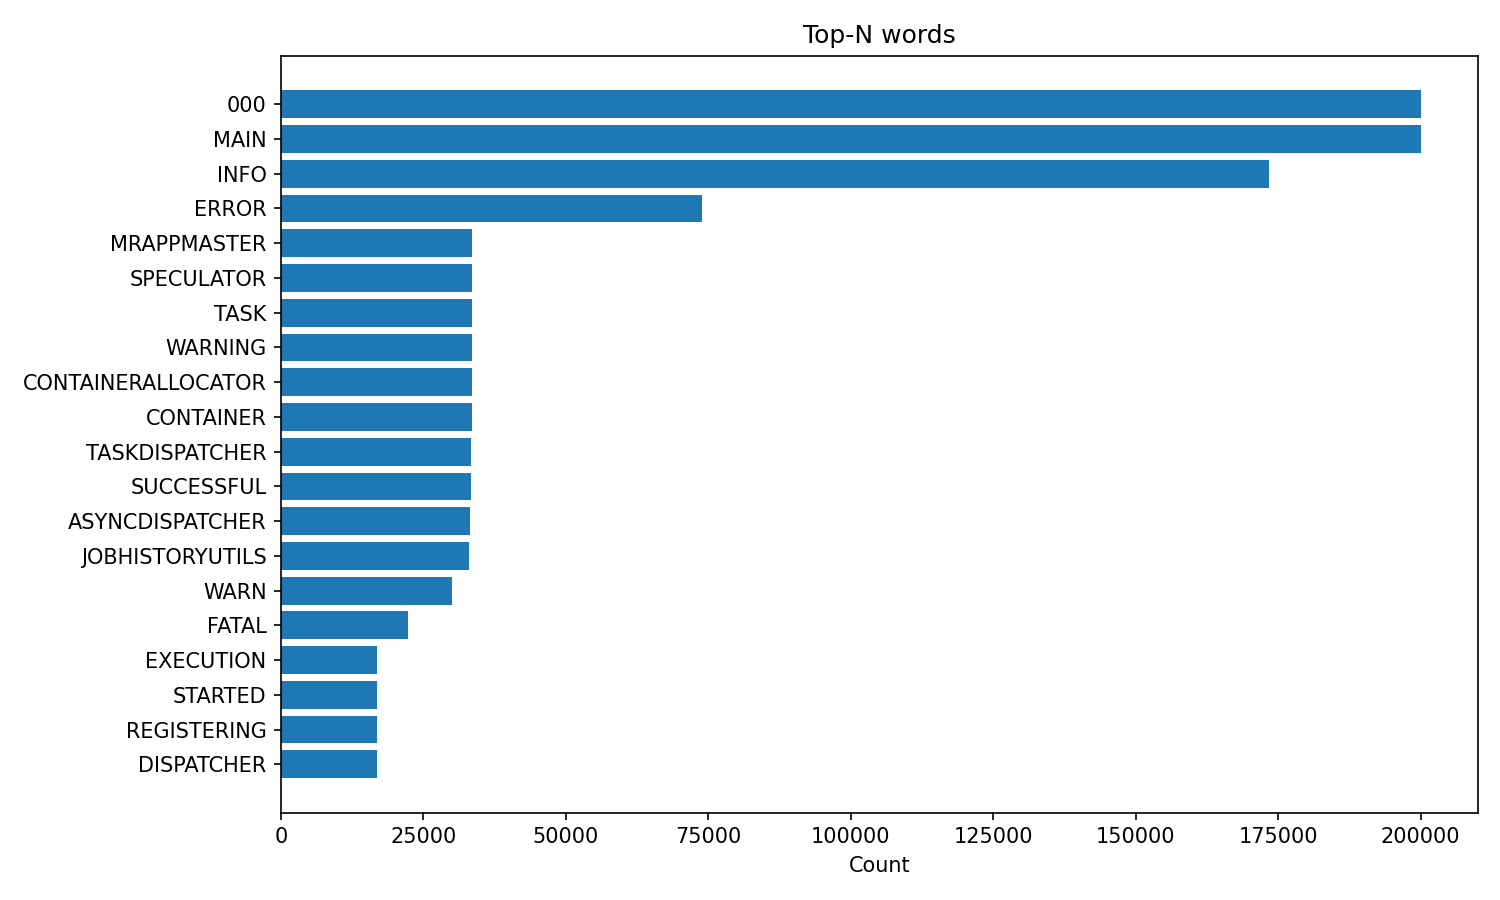

In [29]:
cpu_gpu_plot = PLOTS / "cpu_gpu_throughput.png"
top_words_plot = PLOTS / "top_words.png"

if cpu_gpu_plot.exists():
    display(Image(filename=str(cpu_gpu_plot)))
else:
    print("Brak wykresu CPU/GPU - prawdopodobnie matplotlib nie jest zainstalowany w tym kernelu.")

if top_words_plot.exists():
    display(Image(filename=str(top_words_plot)))
else:
    print("Brak wykresu top-N - prawdopodobnie matplotlib nie jest zainstalowany w tym kernelu.")

In [30]:
report_md = REPORTS / "benchmark_report.md"
if report_md.exists():
    display(Markdown(report_md.read_text(encoding="utf-8")))
else:
    print("Raport markdown nie zostal jeszcze wygenerowany.")

# Benchmark report

- Input bytes: 15562516
- Input size GB: 0.015563
- File read time s: 0.022908
- File read throughput GB/s: 0.679346

## CPU/GPU comparison

| Technology | Mode | Time s | Throughput GB/s | Tokens |
|---|---:|---:|---:|---:|
| CPU OpenMP-like | 4 workers | 0.170246 | 0.091412 | 1649983 |
| GPU CUDA | cuda | 0.231264 | 0.067293 | 1649983 |

## Top words

| Word | Count |
|---|---:|
| 000 | 200000 |
| MAIN | 200000 |
| INFO | 173322 |
| ERROR | 73814 |
| MRAPPMASTER | 33527 |
| SPECULATOR | 33515 |
| TASK | 33473 |
| WARNING | 33466 |
| CONTAINERALLOCATOR | 33455 |
| CONTAINER | 33437 |
| TASKDISPATCHER | 33269 |
| SUCCESSFUL | 33260 |
| ASYNCDISPATCHER | 33191 |
| JOBHISTORYUTILS | 33043 |
| WARN | 30092 |
| FATAL | 22285 |
| EXECUTION | 16812 |
| STARTED | 16812 |
| REGISTERING | 16794 |
| DISPATCHER | 16794 |

## I/O bottleneck conclusion

I/O nie dominuje w tym pomiarze; wiekszy koszt jest po stronie obliczen.


## 13) Porównanie wydajności: OpenMP-like i MPI

Poniżej znajduje się porównanie OpenMP-like i MPI. Porównanie CPU/GPU oraz przepustowość GB/s są generowane w sekcji 12.

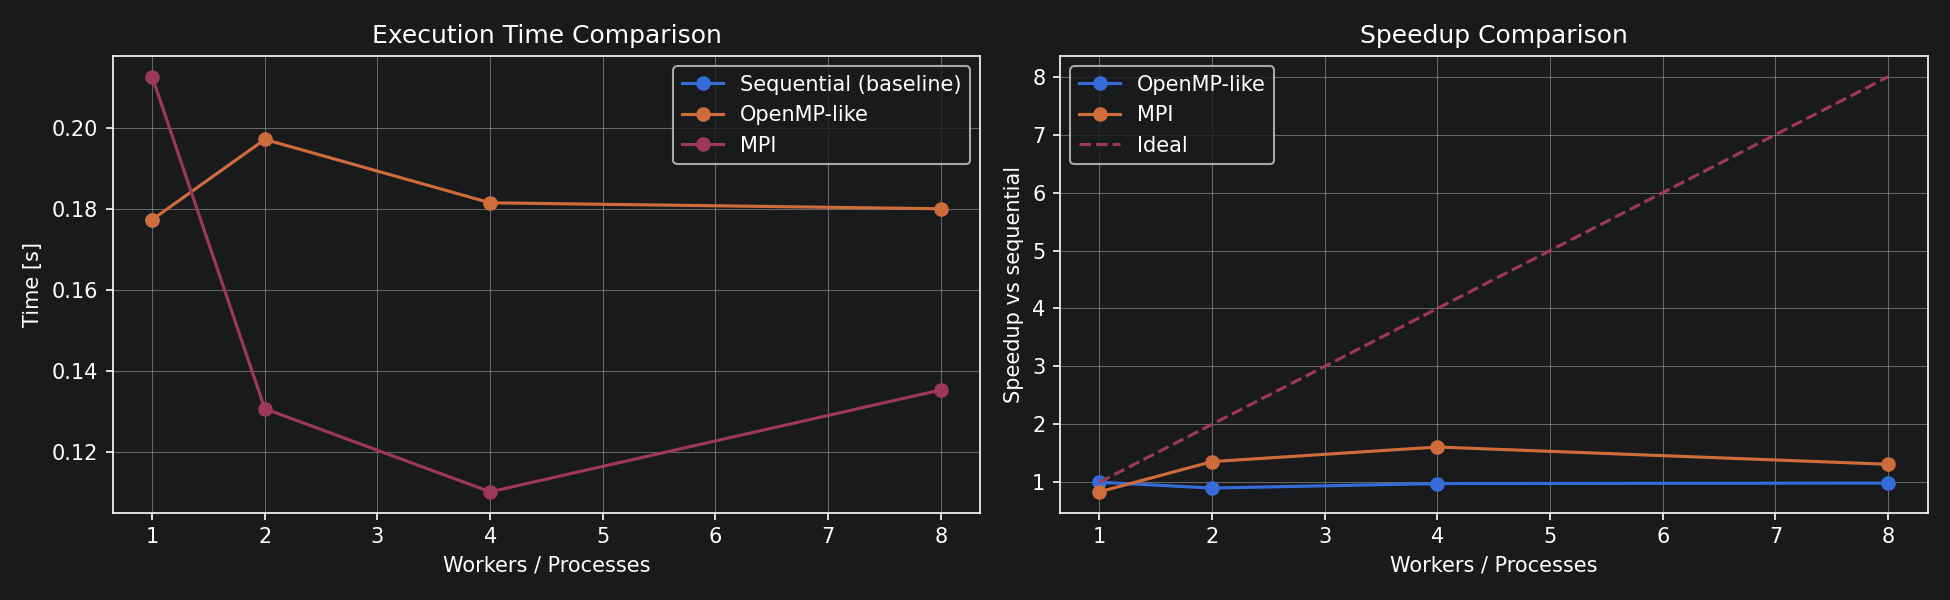

{'sequential_time_s': 0.177333,
 'best_openmp_time_s': 0.177333,
 'best_mpi_time_s': 0.110285}

In [31]:
import csv
from importlib import reload
import visualization.plots as plots_module

reload(plots_module)
plot_parallel_comparison = plots_module.plot_parallel_comparison

openmp_path = REPORTS / "benchmark_openmp.csv"
mpi_path = REPORTS / "benchmark_mpi.csv"
openmp_rows = []
with open(openmp_path, "r", encoding="utf-8") as f:
    for row in csv.DictReader(f):
        openmp_rows.append({"units": int(row["threads"]), "time": float(row["time"])})

mpi_rows = []
with open(mpi_path, "r", encoding="utf-8") as f:
    for row in csv.DictReader(f):
        mpi_rows.append({"units": int(row["processes"]), "time": float(row["time"])})

comparison_plot = PLOTS / "parallel_comparison.png"
summary = plot_parallel_comparison(openmp_rows, mpi_rows, save_path=str(comparison_plot))
display(Image(filename=str(comparison_plot)))
summary

## Podsumowanie

Notebook pokazuje pełną ścieżkę od danych wejściowych do wyników raportowych. Najważniejsze elementy projektu to rozdzielenie parsowania, konfiguracji, analizy, wizualizacji i benchmarków oraz możliwość uruchamiania tych samych funkcji zarówno z notebooka, jak i z CLI.

W praktyce oznacza to, że wyniki można łatwo odtworzyć: mały plik `Hadoop_2k.log` sprawdza poprawność przepływu, a większy `Hadoop_200k.log` nadaje się do benchmarków OpenMP-like, MPI i CUDA.

Projekt nie jest przywiązany do jednego konkretnego pliku wejściowego. Ten sam kod może zostać uruchomiony również na innych, większych plikach logów, o ile zachowują obsługiwany format linii. W repozytorium znajduje się także `Hadoop_200k_old.log`, który może służyć jako dodatkowy wariant danych do testów wydajnościowych i porównania stabilności wyników.